# Preliminar analysis of semantic proximity

This notebook offers an analysis of the distances between speeches once turned into embeddings obtained by a baseline embedding model (here, `Lajavaness/sentence-camembert-large`). It shows the semantic proximity (expressed as the cosinus and euclidean distances) between speeches of a common debate or different debate, agreeing or disagreeing with each other.

Method :
- comparaison between speeches from different debates
- comparaison between speeches of a common debate (_agreeing_ speeches vs _disagreeing_ speeches)
    - distibution of median/mean/standard deviation calculated in each _amendments debate_ 
    - distibution of median/mean/standard deviation calculated in each _article debate_ 
    - distibution of median/mean/standard deviation calculated in each _vote explanation debate_ 
    - distibution of median/mean/standard deviation calculated in each _"motion de rejet" debate_ 

In [2]:
!uv pip install pandas numpy scikit-learn matplotlib

Using Python 3.11.14 environment at: /Users/cesarpichon/Documents/parlement_nlp/.venv
Audited 4 packages in 13ms


In [3]:
import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
import matplotlib.pyplot as plt


## Intra-debate proximity

### Amendments

In [4]:
path = "./embed/intra_amendments.csv"
intervs = pd.read_csv(path, converters={"embedding": literal_eval})

In [5]:
stats = {
    "cosine": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    },
    "euclid": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    }
}

for _, group in intervs.groupby("debate_id"):

    pour = group[group["vote"] == "POUR"]["embedding"].tolist()
    contre = group[group["vote"] == "CONTRE"]["embedding"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

    for label, vec1, vec2 in subsets:

        if len(vec1) < 2 or len(vec2) < 2: 
            continue

        cosine = cosine_distances(vec1, vec2)
        euclid = euclidean_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]
            euclid = euclid[rows, cols]


        stats["cosine"][label]["mean"].append(np.mean(cosine))
        stats["euclid"][label]["mean"].append(np.mean(euclid))
        
        stats["cosine"][label]["median"].append(np.median(cosine))
        stats["euclid"][label]["median"].append(np.median(euclid))

        stats["cosine"][label]["deviation"].append(np.std(cosine))
        stats["euclid"][label]["deviation"].append(np.std(euclid))

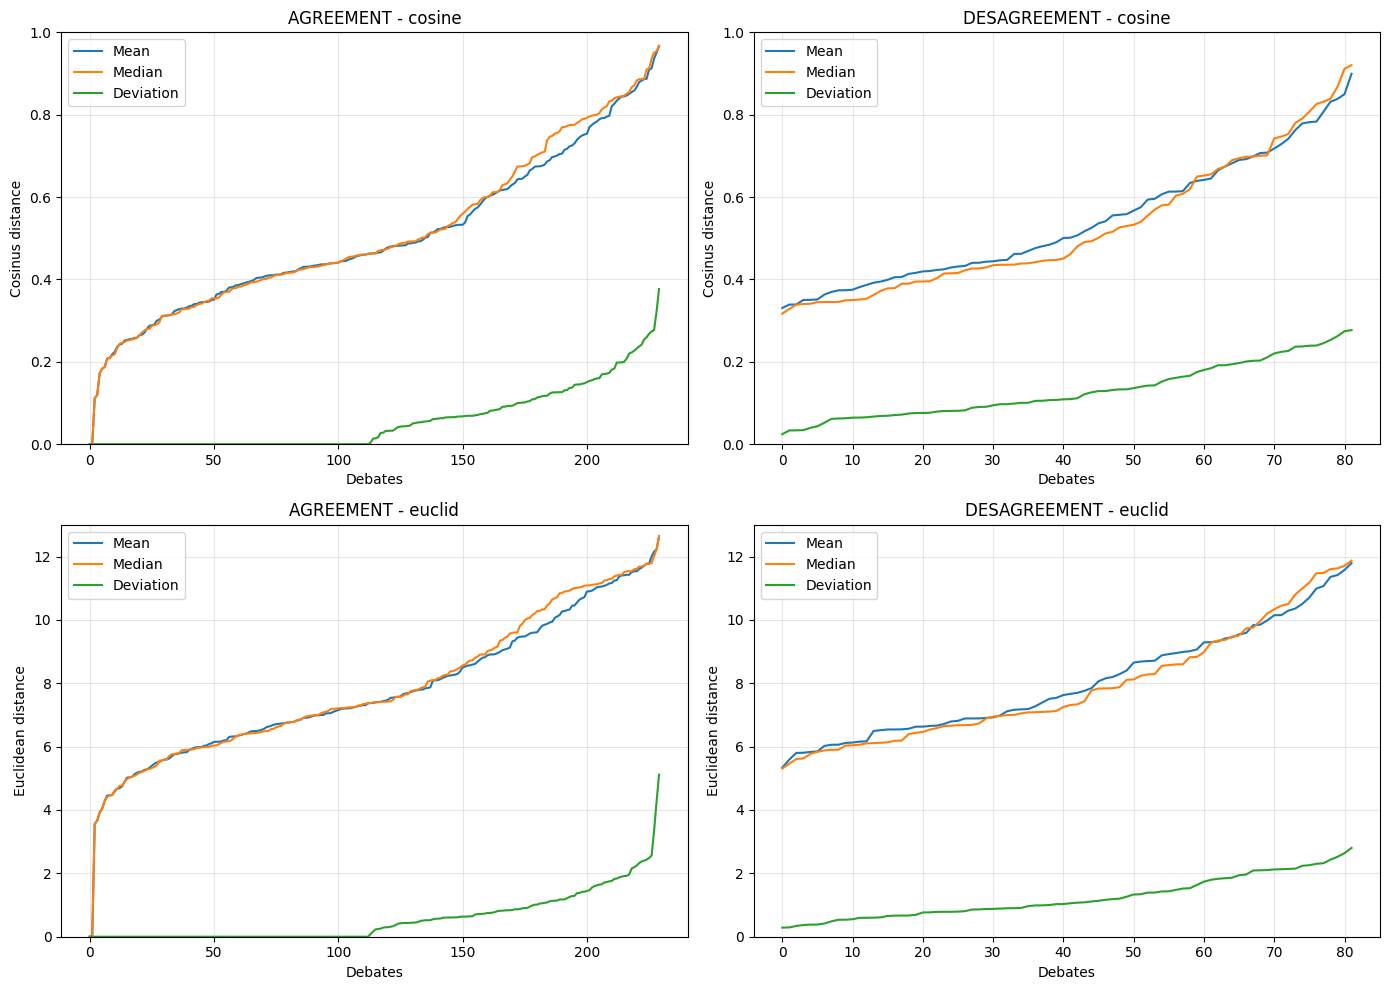

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

labels = ["AGREEMENT", "DESAGREEMENT"]
metrics = [
    ("cosine", "Cosinus distance"),
    ("euclid", "Euclidean distance"),
]

for i, (metric_key, ylabel) in enumerate(metrics):
    for j, vote_label in enumerate(labels):

        ax = axes[i, j]
        sub_stats = stats[metric_key][vote_label]

        for key, curve_label in [("mean", "Mean"), ("median", "Median"), ("deviation", "Deviation")]:
            values = np.sort(np.array(sub_stats[key]))
            ax.plot(values, label=curve_label)

        ax.set_title(f"{vote_label} - {metric_key}")
        ax.set_xlabel("Debates")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        if metric_key == "cosine":
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 13)

plt.tight_layout()
plt.show()

### Vote explanation

In [7]:
path = "./embed/intra_other.csv"
intervs = pd.read_csv(path, converters={"embedding": literal_eval})
intervs = intervs[intervs["source"] == "explication_vote"]

In [8]:
stats = {
    "cosine": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    },
    "euclid": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    }
}

for _, group in intervs.groupby("debate_id"):

    pour = group[group["vote"] == "POUR"]["embedding"].tolist()
    contre = group[group["vote"] == "CONTRE"]["embedding"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

    for label, vec1, vec2 in subsets:

        if len(vec1) < 2 or len(vec2) < 2: 
            continue

        cosine = cosine_distances(vec1, vec2)
        euclid = euclidean_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]
            euclid = euclid[rows, cols]


        stats["cosine"][label]["mean"].append(np.mean(cosine))
        stats["euclid"][label]["mean"].append(np.mean(euclid))
        
        stats["cosine"][label]["median"].append(np.median(cosine))
        stats["euclid"][label]["median"].append(np.median(euclid))

        stats["cosine"][label]["deviation"].append(np.std(cosine))
        stats["euclid"][label]["deviation"].append(np.std(euclid))

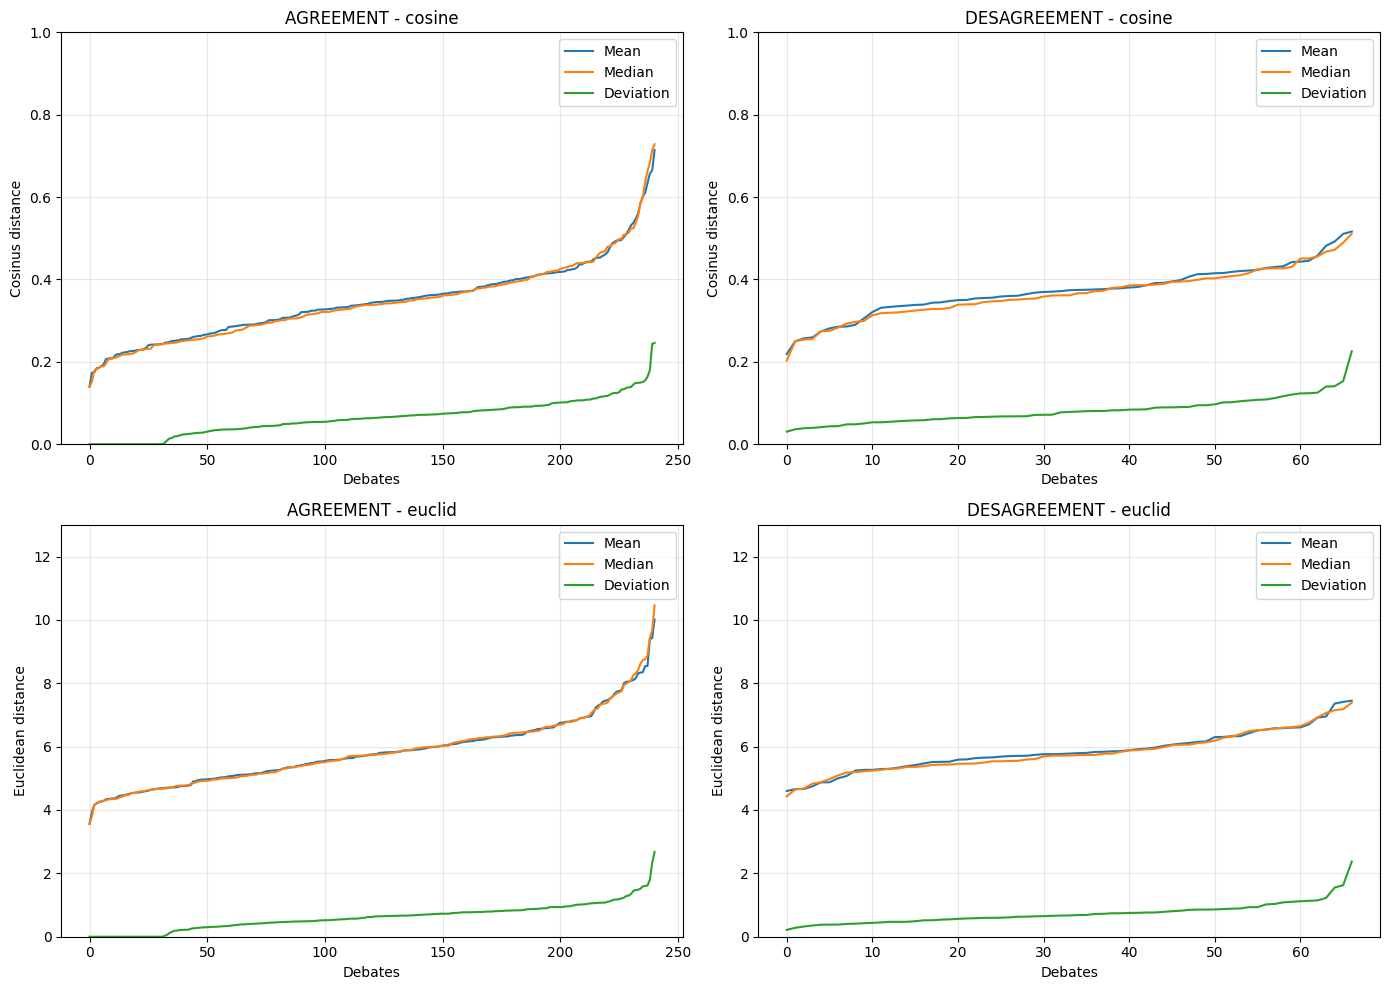

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

labels = ["AGREEMENT", "DESAGREEMENT"]
metrics = [
    ("cosine", "Cosinus distance"),
    ("euclid", "Euclidean distance"),
]

for i, (metric_key, ylabel) in enumerate(metrics):
    for j, vote_label in enumerate(labels):

        ax = axes[i, j]
        sub_stats = stats[metric_key][vote_label]

        for key, curve_label in [("mean", "Mean"), ("median", "Median"), ("deviation", "Deviation")]:
            values = np.sort(np.array(sub_stats[key]))
            ax.plot(values, label=curve_label)

        ax.set_title(f"{vote_label} - {metric_key}")
        ax.set_xlabel("Debates")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        if metric_key == "cosine":
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 13)

plt.tight_layout()
plt.show()

### Articles

In [10]:
path = "./embed/intra_other.csv"
intervs = pd.read_csv(path, converters={"embedding": literal_eval})
intervs = intervs[intervs["source"] == "article"]

In [11]:
stats = {
    "cosine": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    },
    "euclid": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    }
}

for _, group in intervs.groupby("debate_id"):

    pour = group[group["vote"] == "POUR"]["embedding"].tolist()
    contre = group[group["vote"] == "CONTRE"]["embedding"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

    for label, vec1, vec2 in subsets:

        if len(vec1) < 2 or len(vec2) < 2: 
            continue

        cosine = cosine_distances(vec1, vec2)
        euclid = euclidean_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]
            euclid = euclid[rows, cols]


        stats["cosine"][label]["mean"].append(np.mean(cosine))
        stats["euclid"][label]["mean"].append(np.mean(euclid))
        
        stats["cosine"][label]["median"].append(np.median(cosine))
        stats["euclid"][label]["median"].append(np.median(euclid))

        stats["cosine"][label]["deviation"].append(np.std(cosine))
        stats["euclid"][label]["deviation"].append(np.std(euclid))

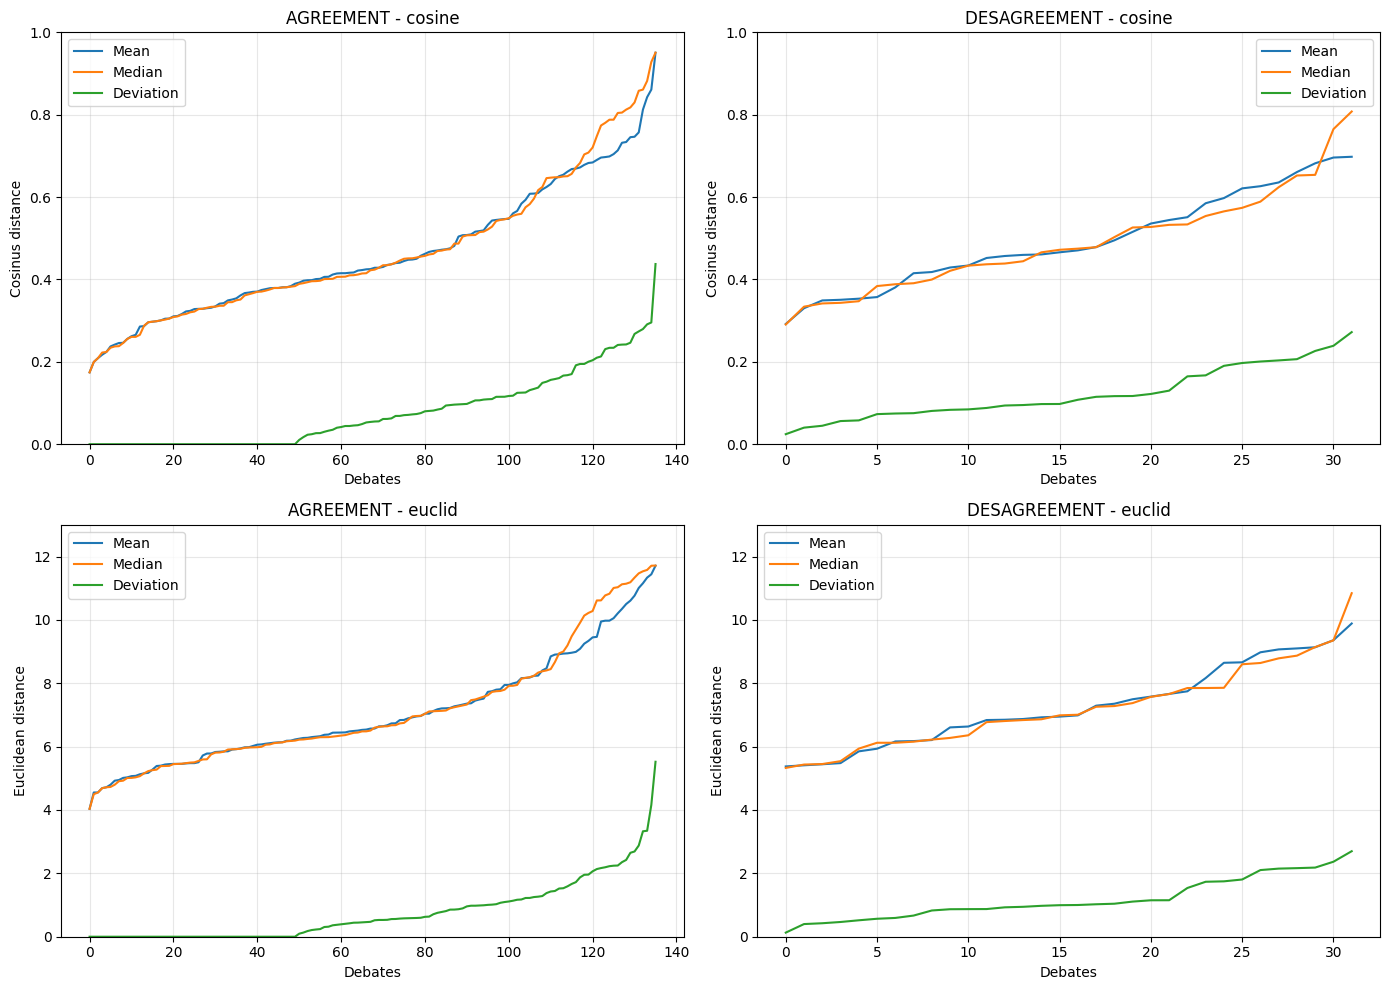

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

labels = ["AGREEMENT", "DESAGREEMENT"]
metrics = [
    ("cosine", "Cosinus distance"),
    ("euclid", "Euclidean distance"),
]

for i, (metric_key, ylabel) in enumerate(metrics):
    for j, vote_label in enumerate(labels):

        ax = axes[i, j]
        sub_stats = stats[metric_key][vote_label]

        for key, curve_label in [("mean", "Mean"), ("median", "Median"), ("deviation", "Deviation")]:
            values = np.sort(np.array(sub_stats[key]))
            ax.plot(values, label=curve_label)

        ax.set_title(f"{vote_label} - {metric_key}")
        ax.set_xlabel("Debates")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        if metric_key == "cosine":
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 13)

plt.tight_layout()
plt.show()

### Motion de rejet

In [13]:
path = "./embed/intra_other.csv"
intervs = pd.read_csv(path, converters={"embedding": literal_eval})
intervs = intervs[intervs["source"] == "motion_rejet"]

In [14]:
stats = {
    "cosine": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    },
    "euclid": {
        "AGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        },
        "DESAGREEMENT": {
            "mean": [],
            "median": [],
            "deviation": []
        }
    }
}

for _, group in intervs.groupby("debate_id"):

    pour = group[group["vote"] == "POUR"]["embedding"].tolist()
    contre = group[group["vote"] == "CONTRE"]["embedding"].tolist()

    subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))

    for label, vec1, vec2 in subsets:

        if len(vec1) < 2 or len(vec2) < 2: 
            continue

        cosine = cosine_distances(vec1, vec2)
        euclid = euclidean_distances(vec1, vec2)

        if label == "AGREEMENT":
            rows, cols = np.triu_indices(cosine.shape[0], k=1)
            cosine = cosine[rows, cols]
            euclid = euclid[rows, cols]


        stats["cosine"][label]["mean"].append(np.mean(cosine))
        stats["euclid"][label]["mean"].append(np.mean(euclid))
        
        stats["cosine"][label]["median"].append(np.median(cosine))
        stats["euclid"][label]["median"].append(np.median(euclid))

        stats["cosine"][label]["deviation"].append(np.std(cosine))
        stats["euclid"][label]["deviation"].append(np.std(euclid))

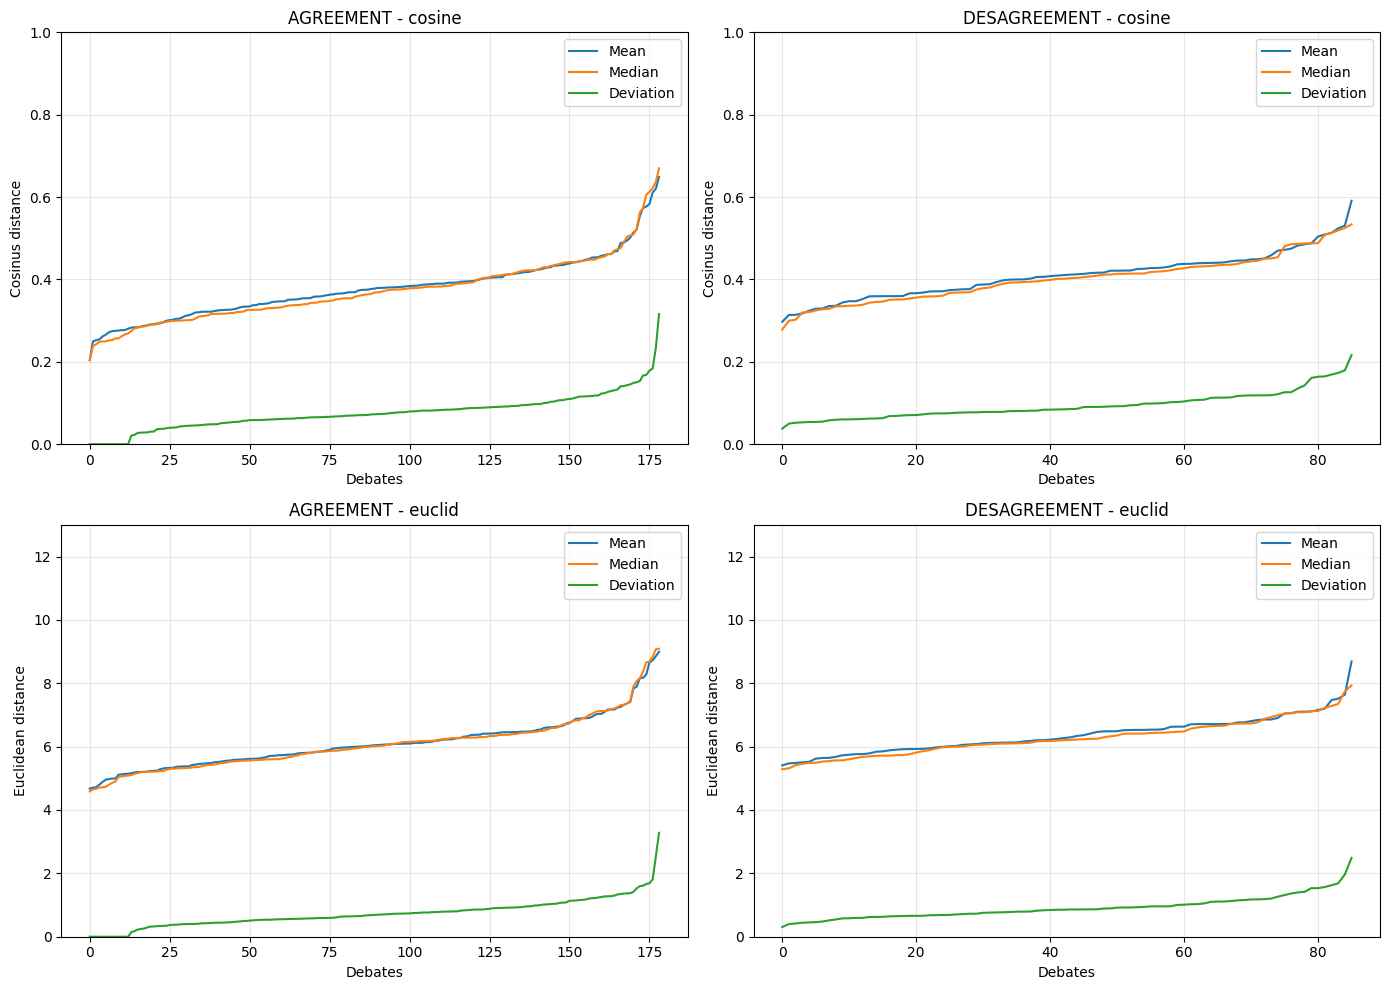

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

labels = ["AGREEMENT", "DESAGREEMENT"]
metrics = [
    ("cosine", "Cosinus distance"),
    ("euclid", "Euclidean distance"),
]

for i, (metric_key, ylabel) in enumerate(metrics):
    for j, vote_label in enumerate(labels):

        ax = axes[i, j]
        sub_stats = stats[metric_key][vote_label]

        for key, curve_label in [("mean", "Mean"), ("median", "Median"), ("deviation", "Deviation")]:
            values = np.sort(np.array(sub_stats[key]))
            ax.plot(values, label=curve_label)

        ax.set_title(f"{vote_label} - {metric_key}")
        ax.set_xlabel("Debates")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.legend()
        if metric_key == "cosine":
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(0, 13)

plt.tight_layout()
plt.show()

## Inter-debate proximity

In [16]:
path = "./embed/inter_sample.csv"
intervs = pd.read_csv(path, converters={"embedding": literal_eval})

In [17]:
stats = {
    "AGREEMENT": {
        "euclid": [],
        "cosine": []
    },
    "DESAGREEMENT": {
        "euclid": [],
        "cosine": []
    }
}

pour = intervs[intervs["vote"] == "POUR"]["embedding"].tolist()
contre = intervs[intervs["vote"] == "CONTRE"]["embedding"].tolist()

subsets = (("AGREEMENT", pour, pour), ("AGREEMENT", contre, contre), ("DESAGREEMENT", pour, contre))
for label, vec1, vec2 in subsets:
    cosine = cosine_distances(vec1, vec2)
    euclid = euclidean_distances(vec1, vec2)

    if label == "AGREEMENT":
        rows, cols = np.triu_indices(cosine.shape[0], k=1)
        cosine = cosine[rows, cols]
        euclid = euclid[rows, cols]

    stats[label]["cosine"] += cosine.copy().flatten().tolist()
    stats[label]["euclid"] += euclid.copy().flatten().tolist()

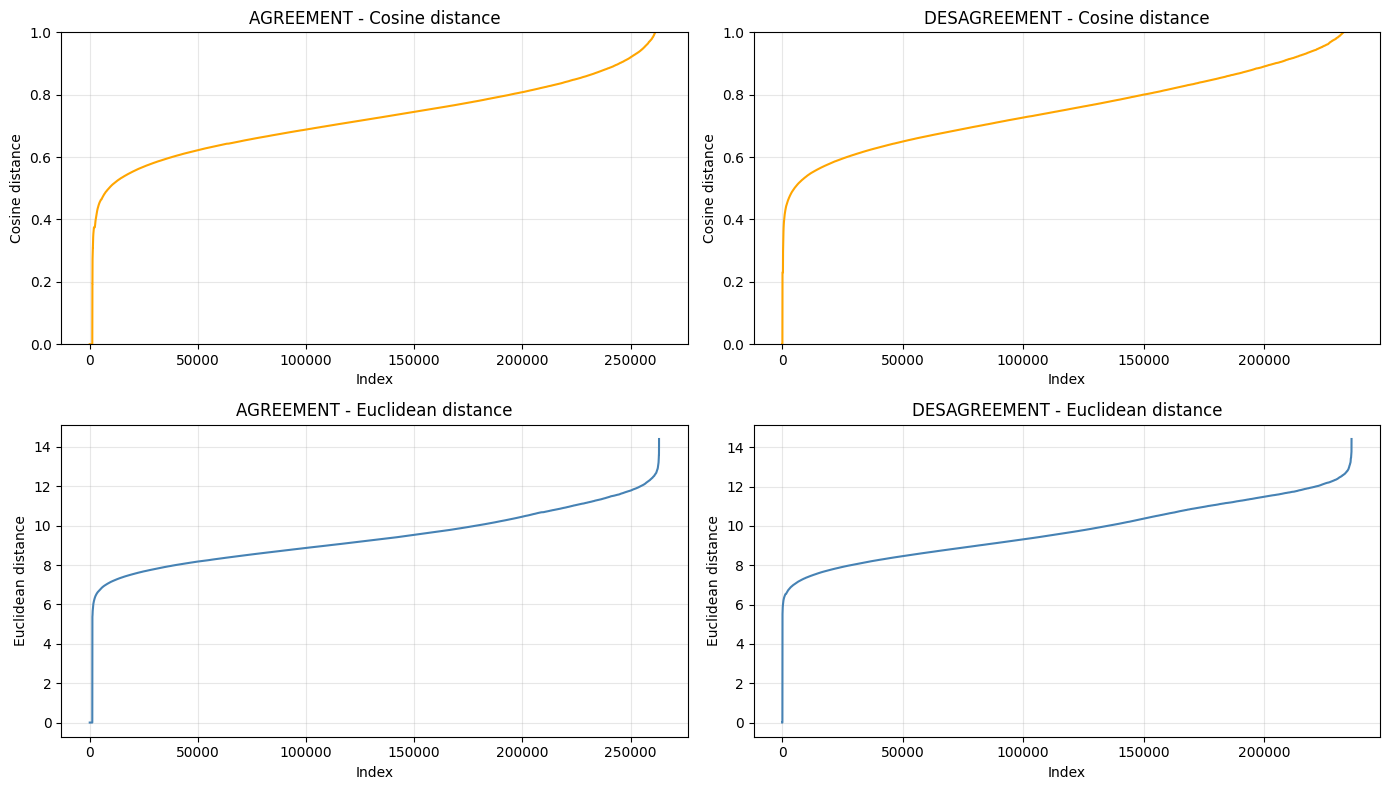

In [18]:
labels = ["AGREEMENT", "DESAGREEMENT"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

for j, vote_label in enumerate(labels):
    cosine_vals = stats[vote_label]["cosine"]
    euclid_vals = stats[vote_label]["euclid"]

    if cosine_vals is None or euclid_vals is None:
        continue

    ordered_cosine = np.sort(np.asarray(cosine_vals).ravel())
    ordered_euclid = np.sort(np.asarray(euclid_vals).ravel())

    axes[0, j].plot(ordered_cosine, color="orange")
    axes[0, j].set_title(f"{vote_label} - Cosine distance")
    axes[0, j].set_xlabel("Index")
    axes[0, j].set_ylabel("Cosine distance")
    axes[0, j].set_ylim(0, 1)
    axes[0, j].grid(alpha=0.3)

    axes[1, j].plot(ordered_euclid, color="steelblue")
    axes[1, j].set_title(f"{vote_label} - Euclidean distance")
    axes[1, j].set_xlabel("Index")
    axes[1, j].set_ylabel("Euclidean distance")
    
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()